<a href="https://colab.research.google.com/github/EddieCarrera/pico-tinyML/blob/main/pico_tinyML_helloWorld_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train a Simple TensorFlow Lite for Microcontrollers model

This notebook demonstrates the process of training a 2.5 kB model using TensorFlow and converting it for use with TensorFlow Lite for Microcontrollers.

Deep learning networks learn to model patterns in underlying data. Here, we're going to train a network to model data generated by a [sine](https://en.wikipedia.org/wiki/Sine) function. This will result in a model that can take a value, `x`, and predict its sine, `y`.


##  Setup Enviroment

In [110]:
# Install tensorflow
! pip install tensorflow;

# Define paths to model files
import os
MODELS_DIR = 'models/'
if not os.path.exists(MODELS_DIR):
    os.mkdir(MODELS_DIR)
MODEL_TF = MODELS_DIR + 'model'
MODEL_NO_QUANT_TFLITE = MODELS_DIR + 'model_no_quant.tflite'
MODEL_TFLITE = MODELS_DIR + 'model.tflite'
MODEL_TFLITE_MICRO = MODELS_DIR + 'model.cc'



In [111]:
# Install modules
# TensorFlow is an open source machine learning library
import tensorflow as tf
# Keras is TensorFlow's high-level API for deep learning
from tensorflow import keras
# Numpy is a math library
import numpy as np
# Pandas is a data manipulation library
import pandas as pd
# Matplotlib is a graphing library
import matplotlib.pyplot as plt
# Math is Python's math library
import math

# Set seed for experiment reproducibility
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)



 ## Generate data

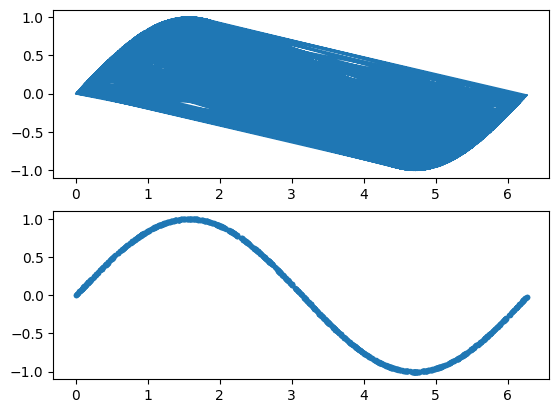

In [112]:
# Create a sine wave fed by random x values
samples  = 1000;
x_values = np.random.uniform(low = 0, high = 2*np.pi, size = samples)

# Second, after generating the data, we shuffle it. This is important because
# the training process used in deep learning depends on data being fed to it in
# a truly random order. If the data were in order, the resulting model would be
# less accurate.
np.random.shuffle(x_values)

# The first subplot is meant to show that the x values are indeed out of
# order
y_values = np.sin(x_values)
fig, axs = plt.subplots(2)
axs[0].plot(x_values, y_values)
axs[1].plot(x_values, y_values, '.')

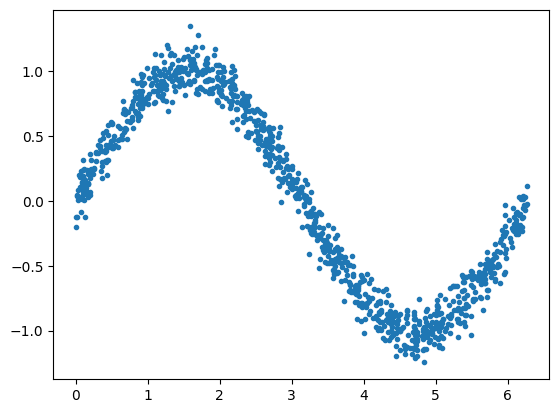

In [113]:
# Now add noise to simulate real world
gaussian_mean = 0
gaussian_std = 0.1
y_values += np.random.normal(gaussian_mean, gaussian_std, samples)
plt.plot(x_values, y_values, '.')

## Splitting the data

We now have a noisy dataset that approximates real world data. We'll be using this to train our model.

To evaluate the accuracy of the model we train, we'll need to compare its predictions to real data and check how well they match up. This evaluation happens during training (where it is referred to as validation) and after training (referred to as testing) It's important in both cases that we use fresh data that was not already used to train the model.

The data is split as follows:

1. Training: 70%
2. Validation: 20%
3. Testing: 10%

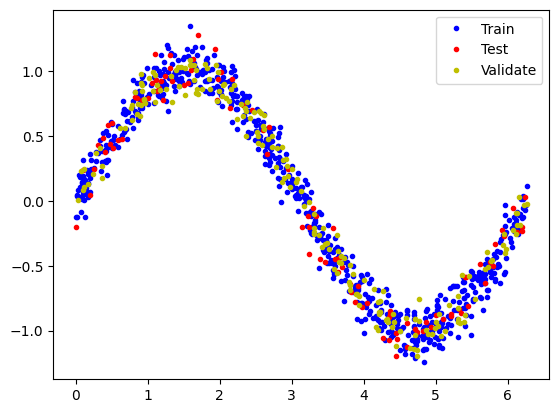

In [114]:
training_size = int(0.7*samples)
validation_size = int(0.2*samples)
trainingIdx = training_size
validationIdx = trainingIdx + validation_size

# Use np.split to chop our data into three parts.
# The second argument to np.split is an array of indices where the data will be
# split. We provide two indices, so the data will be divided into three chunks.
x_train, x_valid, x_test = np.split(x_values, [trainingIdx, validationIdx])
y_train, y_valid, y_test = np.split(y_values, [trainingIdx, validationIdx])

assert(x_train.size + x_valid.size + x_test.size == samples)

# Plot the data in each partition in different colors:
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_valid, y_valid, 'y.', label="Validate")
plt.legend()
plt.show()
